## Image Segmentation
Part 1 of image segment analysis, segmenting images with Python. Code from opensourceoptions.com resources and tutorial. https://opensourceoptions.com/python-geographic-object-based-image-analysis-geobia/

In [40]:
# Importing Packages
import numpy as np
from skimage import exposure
from skimage.segmentation import quickshift, slic, mark_boundaries
import time
import scipy
import matplotlib.pyplot as plt
from osgeo import gdal
from osgeo import ogr
from osgeo import osr
from osgeo import gdal_array
import os

In [41]:
os.chdir('/home/jovyan/project/trees_n_shrimps')
camau2026_fn = 'ca_mau_2026_48PVQ.tif'

In [42]:
# Open the dataset
driverTiff = gdal.GetDriverByName('GTiff')
camau2026_ds = gdal.Open(camau2026_fn)

# Check it opened correctly
if camau2026_ds is None:
    raise FileNotFoundError(f"Could not open file: {camau2026_fn}")

nbands = camau2026_ds.RasterCount
print('bands', camau2026_ds.RasterCount, 'rows', camau2026_ds.RasterYSize, 'columns', camau2026_ds.RasterXSize)

# Read all bands into a stacked array
band_data = []
for i in range(1, nbands + 1):
    band = camau2026_ds.GetRasterBand(i).ReadAsArray()
    band_data.append(band)

band_data = np.dstack(band_data)
print('Array shape:', band_data.shape)  # (rows, cols, bands)

bands 8 rows 1660 columns 2202
Array shape: (1660, 2202, 8)


In [43]:
# Segmentation done using scikit-image.

# scale image values from 0.0 - 1.0
img = exposure.rescale_intensity(band_data)

# do segmentation multiple options with quickshift and slic
# figure out which option works best (see examples right below)
seg_start = time.time()
# segments = quickshift(img, convert2lab=False)
# segments = quickshift(img, ratio=0.8, convert2lab=False)
# segments = quickshift(img, ratio=0.99, max_dist=5, convert2lab=False)
# segments = slic(img, n_segments=100000, compactness=0.1)
# segments = slic(img, n_segments=500000, compactness=0.01)
segments2026 = slic(img, n_segments=50000, compactness=0.1)
print('segments complete', time.time() - seg_start)

# save segments to raster
segments2026_fn = 'segments2026.tif'
segments2026_ds = driverTiff.Create(segments2026_fn, camau2026_ds.RasterXSize, camau2026_ds.RasterYSize,
                                1, gdal.GDT_Float32)
segments2026_ds.SetGeoTransform(camau2026_ds.GetGeoTransform())
segments2026_ds.SetProjection(camau2026_ds.GetProjectionRef())
segments2026_ds.GetRasterBand(1).WriteArray(segments)
segments2026_ds = None

print('Unique segments:', len(np.unique(segments)))
print('Image shape:', img.shape)
print('Segments shape:', segments.shape)
print('Segments min/max:', segments.min(), segments.max())

segments complete 4.368036508560181
Unique segments: 385174
Image shape: (1660, 2202, 8)
Segments shape: (1660, 2202)
Segments min/max: 1 385174


Text(0.5, 1.0, '2026 Segmentation result: 385174 segments')

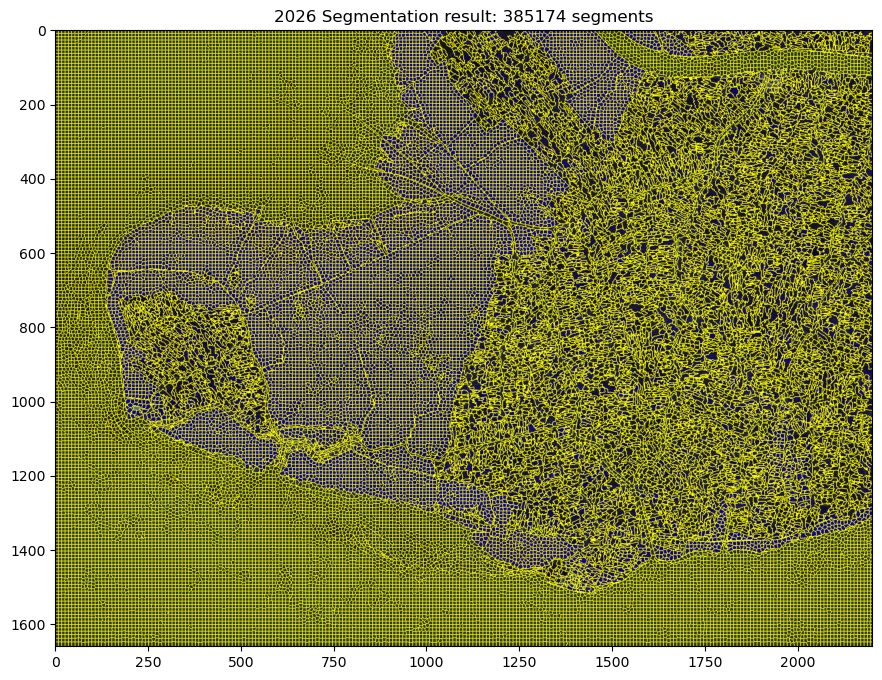

In [44]:
rgb = exposure.rescale_intensity(band_data[:, :, :3].astype(float))
plt.figure(figsize=(12, 8))
plt.imshow(mark_boundaries(rgb, segments2026))
plt.title(f'2026 Segmentation result: {len(np.unique(segments))} segments')

In [45]:
# Describing each segment based on spectral properties: 
# spectral properties = variables that will classify each segment as a land cover type.

# Function that returns the min, max, mean, variance, skewness, and kurtois for each band in a given array of pixels.
def segment_features(segment_pixels):
    features = []
    npixels, nbands = segment_pixels.shape
    for b in range(nbands):
        stats = scipy.stats.describe(segment_pixels[:, b])
        band_stats = list(stats.minmax) + list(stats)[2:]
        if npixels == 1:
            # in this case the variance = nan, change it 0.0
            band_stats[3] = 0.0
        features += band_stats
    return features

In [46]:
# Makes a list of segment ID numbers and the pixels for each are passed to segment_features.
# Statistics from segment_features are stored in objects list, and object_id stored in a separate list.
# May take several hours to run, depending on setup. 

segment2026_ids = np.unique(segments2026)
objects = []
object_ids = []
for id in segment2026_ids:
    segment_pixels = img[segments == id]
    object_features = segment_features(segment_pixels)
    objects.append(object_features)
    object_ids.append(id)

/tmp/ipykernel_3502/1871124841.py:9: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  stats = scipy.stats.describe(segment_pixels[:, b])
/opt/conda/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  sk = skew(a, axis, bias=bias)
/opt/conda/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1524: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurt = kurtosis(a, axis, bias=bias)


KeyboardInterrupt: 